# 模型選擇、欠擬合和過擬合
:label:`sec_model_selection`

作為機器學習科學家，我們的目標是發現*模式*（pattern）。
但是，我們如何才能確定模型是真正發現了一種泛化的模式，
而不是簡單地記住了數據呢？
例如，我們想要在患者的基因數據與癡呆狀態之間尋找模式，
其中標籤是從集合$\{\text{癡呆}, \text{輕度認知障礙}, \text{健康}\}$中提取的。
因為基因可以唯一確定每個個體（不考慮雙胞胎），
所以在這個任務中是有可能記住整個數據集的。

我們不想讓模型只會做這樣的事情："那是鮑勃！我記得他！他有癡呆症！"。
原因很簡單：當我們將來部署該模型時，模型需要判斷從未見過的患者。
只有當模型真正發現了一種泛化模式時，才會作出有效的預測。

更正式地說，我們的目標是發現某些模式，
這些模式捕捉到了我們訓練集潛在總體的規律。
如果成功做到了這點，即使是對以前從未遇到過的個體，
模型也可以成功地評估風險。
如何發現可以泛化的模式是機器學習的根本問題。

困難在於，當我們訓練模型時，我們只能訪問數據中的小部分樣本。
最大的公開圖像數據集包含大約一百萬張圖像。
而在大部分時候，我們只能從數千或數萬個數據樣本中學習。
在大型醫院系統中，我們可能會訪問數十萬份醫療記錄。
當我們使用有限的樣本時，可能會遇到這樣的問題：
當收集到更多的數據時，會發現之前找到的明顯關係並不成立。

將模型在訓練數據上擬合的比在潛在分布中更接近的現象稱為*過擬合*（overfitting），
用於對抗過擬合的技術稱為*正則化*（regularization）。
在前面的章節中，有些讀者可能在用Fashion-MNIST數據集做實驗時已經觀察到了這種過擬合現象。
在實驗中調整模型架構或超參數時會發現：
如果有足夠多的神經元、層數和訓練迭代週期，
模型最終可以在訓練集上達到完美的精度，此時測試集的準確性卻下降了。

## 訓練誤差和泛化誤差

為了進一步討論這一現象，我們需要了解訓練誤差和泛化誤差。
*訓練誤差*（training error）是指，
模型在訓練數據集上計算得到的誤差。
*泛化誤差*（generalization error）是指，
模型應用在同樣從原始樣本的分布中抽取的無限多數據樣本時，模型誤差的期望。

問題是，我們永遠不能準確地計算出泛化誤差。
這是因為無限多的數據樣本是一個虛構的對象。
在實際中，我們只能通過將模型應用於一個獨立的測試集來估計泛化誤差，
該測試集由隨機選取的、未曾在訓練集中出現的數據樣本構成。

下面的三個思維實驗將有助於更好地說明這種情況。
假設一個大學生正在努力準備期末考試。
一個勤奮的學生會努力做好練習，並利用往年的考試題目來測試自己的能力。
儘管如此，在過去的考試題目上取得好成績並不能保證他會在真正考試時發揮出色。
例如，學生可能試圖通過死記硬背考題的答案來做準備。
他甚至可以完全記住過去考試的答案。
另一名學生可能會通過試圖理解給出某些答案的原因來做準備。
在大多數情況下，後者會考得更好。

類似地，考慮一個簡單地使用查表法來回答問題的模型。
如果允許的輸入集合是離散的並且相當小，
那麼也許在查看許多訓練樣本後，該方法將執行得很好。
但當這個模型面對從未見過的例子時，它表現的可能比隨機猜測好不到哪去。
這是因為輸入空間太大了，遠遠不可能記住每一個可能的輸入所對應的答案。
例如，考慮$28\times28$的灰度圖像。
如果每個像素可以取$256$個灰度值中的一個，
則有$256^{784}$個可能的圖像。
這意味著指甲大小的低分辨率灰度圖像的數量比宇宙中的原子要多得多。
即使我們可能遇到這樣的數據，我們也不可能存儲整個查找表。

最後，考慮對擲硬幣的結果（類別0：正面，類別1：反面）進行分類的問題。
假設硬幣是公平的，無論我們想出什麼算法，泛化誤差始終是$\frac{1}{2}$。
然而，對於大多數算法，我們應該期望訓練誤差會更低（取決於運氣）。
考慮數據集{0，1，1，1，0，1}。
我們的算法不需要額外的特徵，將傾向於總是預測*多數類*，
從我們有限的樣本來看，它似乎是1占主流。
在這種情況下，總是預測類1的模型將產生$\frac{1}{3}$的誤差，
這比我們的泛化誤差要好得多。
當我們逐漸增加數據量，正面比例明顯偏離$\frac{1}{2}$的可能性將會降低，
我們的訓練誤差將與泛化誤差相匹配。

### 統計學習理論

由於泛化是機器學習中的基本問題，
許多數學家和理論家畢生致力於研究描述這一現象的形式理論。
在[同名定理（eponymous theorem）](https://en.wikipedia.org/wiki/Glivenko%E2%80%93Cantelli_theorem)中，
格里文科和坎特利推導出了訓練誤差收斂到泛化誤差的速率。
在一系列開創性的論文中，
[Vapnik和Chervonenkis](https://en.wikipedia.org/wiki/Vapnik%E2%80%93Chervonenkis_theory)
將這一理論擴展到更一般種類的函數。
這項工作為統計學習理論奠定了基礎。

在我們目前已探討、並將在之後繼續探討的監督學習情景中，
我們假設訓練數據和測試數據都是從相同的分布中獨立提取的。
這通常被稱為*獨立同分布假設*（i.i.d. assumption），
這意味著對數據進行採樣的過程沒有進行"記憶"。
換句話說，抽取的第2個樣本和第3個樣本的相關性，
並不比抽取的第2個樣本和第200萬個樣本的相關性更強。

要成為一名優秀的機器學習科學家需要具備批判性思考能力。
假設是存在漏洞的，即很容易找出假設失效的情況。
如果我們根據從加州大學舊金山分校醫學中心的患者數據訓練死亡風險預測模型，
並將其應用於麻薩諸塞州綜合醫院的患者數據，結果會怎麼樣？
這兩個數據的分布可能不完全一樣。
此外，抽樣過程可能與時間有關。
比如當我們對微博的主題進行分類時，
新聞週期會使得正在討論的話題產生時間依賴性，從而違反獨立性假設。

有時候我們即使輕微違背獨立同分布假設，模型仍將繼續運行得非常好。

比如，我們有許多有用的工具已經應用於現實，如人臉識別、語音識別和語言翻譯。
畢竟，幾乎所有現實的應用都至少涉及到一些違背獨立同分布假設的情況。
有些違背獨立同分布假設的行為肯定會帶來麻煩。
比如，我們試圖只用來自大學生的人臉數據來訓練一個人臉識別系統，
然後想要用它來監測療養院中的老人。
這不太可能有效，因為大學生看起來往往與老年人有很大的不同。

在接下來的章節中，我們將討論因違背獨立同分布假設而引起的問題。
目前，即使認為獨立同分布假設是理所當然的，理解泛化性也是一個困難的問題。
此外，能夠解釋深層神經網絡泛化性能的理論基礎，
也仍在繼續困擾著學習理論領域最偉大的學者們。

有些違背獨立同分布假設的行為肯定會帶來麻煩。
比如，我們試圖只用來自大學生的人臉數據來訓練一個人臉識別系統，
然後想要用它來監測療養院中的老人。
這不太可能有效，因為大學生看起來往往與老年人有很大的不同。

在接下來的章節中，我們將討論因違背獨立同分布假設而引起的問題。
目前，即使認為獨立同分布假設是理所當然的，理解泛化性也是一個困難的問題。
此外，能夠解釋深層神經網絡泛化性能的理論基礎，
也仍在繼續困擾著學習理論領域最偉大的學者們。

當我們訓練模型時，我們試圖找到一個能夠儘可能擬合訓練數據的函數。
但是如果它執行地"太好了"，而不能對看不見的數據做到很好泛化，就會導致過擬合。
這種情況正是我們想要避免或控制的。

深度學習中有許多啟發式的技術旨在防止過擬合。

### 模型複雜性

當我們有簡單的模型和大量的數據時，我們期望泛化誤差與訓練誤差相近。
當我們有更複雜的模型和更少的樣本時，我們預計訓練誤差會下降，但泛化誤差會增大。
模型複雜性由什麼構成是一個複雜的問題。
一個模型是否能很好地泛化取決於很多因素。
例如，具有更多參數的模型可能被認為更複雜，
參數有更大取值範圍的模型可能更為複雜。
通常對於神經網絡，我們認為需要更多訓練迭代的模型比較複雜，
而需要*早停*（early stopping）的模型（即較少訓練迭代週期）就不那麼複雜。

我們很難比較本質上不同大類的模型之間（例如，決策樹與神經網絡）的複雜性。
就目前而言，一條簡單的經驗法則相當有用：
統計學家認為，能夠輕鬆解釋任意事實的模型是複雜的，
而表達能力有限但仍能很好地解釋數據的模型可能更有現實用途。
在哲學上，這與波普爾的科學理論的可證偽性標準密切相關：
如果一個理論能擬合數據，且有具體的測試可以用來證明它是錯誤的，那麼它就是好的。
這一點很重要，因為所有的統計估計都是*事後歸納*。
也就是說，我們在觀察事實之後進行估計，因此容易受到相關謬誤的影響。
目前，我們將把哲學放在一邊，堅持更切實的問題。

本節為了給出一些直觀的印象，我們將重點介紹幾個傾向於影響模型泛化的因素。

1. 可調整參數的數量。當可調整參數的數量（有時稱為*自由度*）很大時，模型往往更容易過擬合。
2. 參數採用的值。當權重的取值範圍較大時，模型可能更容易過擬合。
3. 訓練樣本的數量。即使模型很簡單，也很容易過擬合只包含一兩個樣本的數據集。而過擬合一個有數百萬個樣本的數據集則需要一個極其靈活的模型。

## 模型選擇

在機器學習中，我們通常在評估幾個候選模型後選擇最終的模型。
這個過程叫做*模型選擇*。
有時，需要進行比較的模型在本質上是完全不同的（比如，決策樹與線性模型）。
又有時，我們需要比較不同的超參數設置下的同一類模型。

例如，訓練多層感知機模型時，我們可能希望比較具有
不同數量的隱藏層、不同數量的隱藏單元以及不同的激活函數組合的模型。
為了確定候選模型中的最佳模型，我們通常會使用驗證集。

### 驗證集

原則上，在我們確定所有的超參數之前，我們不希望用到測試集。
如果我們在模型選擇過程中使用測試數據，可能會有過擬合測試數據的風險，那就麻煩大了。
如果我們過擬合了訓練數據，還可以在測試數據上的評估來判斷過擬合。
但是如果我們過擬合了測試數據，我們又該怎麼知道呢？

因此，我們決不能依靠測試數據進行模型選擇。
然而，我們也不能僅僅依靠訓練數據來選擇模型，因為我們無法估計訓練數據的泛化誤差。

在實際應用中，情況變得更加複雜。
雖然理想情況下我們只會使用測試數據一次，
以評估最好的模型或比較一些模型效果，但現實是測試數據很少在使用一次後被丟棄。
我們很少能有充足的數據來對每一輪實驗採用全新測試集。

解決此問題的常見做法是將我們的數據分成三份，
除了訓練和測試數據集之外，還增加一個*驗證數據集*（validation dataset），
也叫*驗證集*（validation set）。
但現實是驗證數據和測試數據之間的邊界模糊得令人擔憂。
除非另有明確說明，否則在這本書的實驗中，
我們實際上是在使用應該被正確地稱為訓練數據和驗證數據的數據集，
並沒有真正的測試數據集。
因此，書中每次實驗報告的準確度都是驗證集準確度，而不是測試集準確度。

### $K$折交叉驗證

當訓練數據稀缺時，我們甚至可能無法提供足夠的數據來構成一個合適的驗證集。
這個問題的一個流行的解決方案是採用$K$*折交叉驗證*。
這裡，原始訓練數據被分成$K$個不重疊的子集。
然後執行$K$次模型訓練和驗證，每次在$K-1$個子集上進行訓練，
並在剩餘的一個子集（在該輪中沒有用於訓練的子集）上進行驗證。
最後，通過對$K$次實驗的結果取平均來估計訓練和驗證誤差。

## 欠擬合還是過擬合？

當我們比較訓練和驗證誤差時，我們要注意兩種常見的情況。
首先，我們要注意這樣的情況：訓練誤差和驗證誤差都很嚴重，
但它們之間僅有一點差距。
如果模型不能降低訓練誤差，這可能意味著模型過於簡單（即表達能力不足），
無法捕獲試圖學習的模式。
此外，由於我們的訓練和驗證誤差之間的*泛化誤差*很小，
我們有理由相信可以用一個更複雜的模型降低訓練誤差。
這種現象被稱為*欠擬合*（underfitting）。

另一方面，當我們的訓練誤差明顯低於驗證誤差時要小心，
這表明嚴重的*過擬合*（overfitting）。
注意，*過擬合*並不總是一件壞事。
特別是在深度學習領域，眾所周知，
最好的預測模型在訓練數據上的表現往往比在保留（驗證）數據上好得多。
最終，我們通常更關心驗證誤差，而不是訓練誤差和驗證誤差之間的差距。

是否過擬合或欠擬合可能取決於模型複雜性和可用訓練數據集的大小，
這兩個點將在下面進行討論。

### 模型複雜性

為了說明一些關於過擬合和模型複雜性的經典直覺，
我們給出一個多項式的例子。
給定由單個特徵$x$和對應實數標籤$y$組成的訓練數據，
我們試圖找到下面的$d$階多項式來估計標籤$y$。

$$\hat{y}= \sum_{i=0}^d x^i w_i$$

這只是一個線性回歸問題，我們的特徵是$x$的冪給出的，
模型的權重是$w_i$給出的，偏置是$w_0$給出的
（因為對於所有的$x$都有$x^0 = 1$）。
由於這只是一個線性回歸問題，我們可以使用平方誤差作為我們的損失函數。

高階多項式函數比低階多項式函數複雜得多。
高階多項式的參數較多，模型函數的選擇範圍較廣。
因此在固定訓練數據集的情況下，
高階多項式函數相對於低階多項式的訓練誤差應該始終更低（最壞也是相等）。
事實上，當數據樣本包含了$x$的不同值時，
函數階數等於數據樣本數量的多項式函數可以完美擬合訓練集。
在 :numref:`fig_capacity_vs_error`中，
我們直觀地描述了多項式的階數和欠擬合與過擬合之間的關係。

![模型複雜度對欠擬合和過擬合的影響](../img/capacity-vs-error.svg)
:label:`fig_capacity_vs_error`

### 數據集大小

另一個重要因素是數據集的大小。
訓練數據集中的樣本越少，我們就越有可能（且更嚴重地）過擬合。
隨著訓練數據量的增加，泛化誤差通常會減小。
此外，一般來說，更多的數據不會有什麼壞處。
對於固定的任務和數據分布，模型複雜性和數據集大小之間通常存在關係。
給出更多的數據，我們可能會嘗試擬合一個更複雜的模型。
能夠擬合更複雜的模型可能是有益的。
如果沒有足夠的數據，簡單的模型可能更有用。
對於許多任務，深度學習只有在有數千個訓練樣本時才優於線性模型。
從一定程度上來說，深度學習目前的生機要歸功於
廉價存儲、互聯設備以及數字化經濟帶來的海量數據集。

## 多項式回歸

我們現在可以(**通過多項式擬合來探索這些概念**)。


In [1]:
import math
import numpy as np
import torch
from torch import nn

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### 生成資料集

給定$x$，我們將[**使用以下三階多項式來生成訓練和測試資料的標籤：**]

(**$$y = 5 + 1.2x - 3.4\frac{x^2}{2!} + 5.6 \frac{x^3}{3!} + \epsilon \text{ where }
\epsilon \sim \mathcal{N}(0, 0.1^2).$$**)

雜訊項$\epsilon$服從均值為0且標準差為0.1的常態分布。
在最佳化的過程中，我們通常希望避免非常大的梯度值或損失值。
這就是我們將特徵從$x^i$調整為$\frac{x^i}{i!}$的原因，
這樣可以避免很大的$i$帶來的特別大的指數值。
我們將為訓練集和測試集各生成100個樣本。


In [2]:
max_degree = 20  # 多項式的最大階數
n_train, n_test = 100, 100  # 訓練和測試資料集大小
true_w = np.zeros(max_degree)  # 分配大量的空間
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
# labels的維度:(n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

同樣，存儲在`poly_features`中的單項式由gamma函數重新縮放，
其中$\Gamma(n)=(n-1)!$。
從生成的資料集中[**查看一下前2個樣本**]，
第一個值是與偏置相對應的常量特徵。


In [3]:
# NumPy ndarray轉換為tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]

In [4]:
features[:2], poly_features[:2, :], labels[:2]

(tensor([[ 0.1444],
         [-0.5828]]),
 tensor([[ 1.0000e+00,  1.4445e-01,  1.0432e-02,  5.0230e-04,  1.8139e-05,
           5.2402e-07,  1.2615e-08,  2.6032e-10,  4.7003e-12,  7.5438e-14,
           1.0897e-15,  1.4309e-17,  1.7224e-19,  1.9138e-21,  1.9746e-23,
           1.9015e-25,  1.7166e-27,  1.4586e-29,  1.1705e-31,  8.8984e-34],
         [ 1.0000e+00, -5.8277e-01,  1.6981e-01, -3.2987e-02,  4.8060e-03,
          -5.6015e-04,  5.4407e-05, -4.5295e-06,  3.2996e-07, -2.1366e-08,
           1.2451e-09, -6.5966e-11,  3.2036e-12, -1.4361e-13,  5.9781e-15,
          -2.3226e-16,  8.4595e-18, -2.9000e-19,  9.3890e-21, -2.8798e-22]]),
 tensor([5.2203, 3.6428]))

### 對模型進行訓練和測試

首先讓我們[**實現一個函數來評估模型在給定資料集上的損失**]。


In [5]:
def evaluate_loss(net, data_iter, loss_fn):
    """評估給定資料集上模型的損失"""
    # 設置為評估模式
    net.eval()
    
    total_loss = 0
    total_samples = 0
    
    # 不計算梯度
    with torch.no_grad():
        for X, y in data_iter:
            # 如果模型在GPU上，將數據移到相應設備
            device = next(net.parameters()).device
            X, y = X.to(device), y.to(device)
            
            # 前向傳播
            out = net(X)
            y = y.reshape(out.shape)
            
            # 計算損失
            l = loss_fn(out, y)
            
            # 累加損失和樣本數
            total_loss += l.sum().item()
            total_samples += l.numel()
    
    # 返回平均損失
    return total_loss / total_samples

# 使用示例：
# loss = evaluate_loss(net, test_iter, loss_fn)
# print(f'Average loss: {loss:.4f}')

現在[**定義訓練函數**]。


In [6]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

def load_array(data_arrays, batch_size, is_train=True):
    """構造一個PyTorch數據迭代器"""
    dataset = TensorDataset(*data_arrays)
    return DataLoader(dataset, batch_size, shuffle=is_train)

def evaluate_loss(net, data_iter, loss_fn):
    """評估給定數據集上的損失"""
    net.eval()
    total_loss = 0
    total_samples = 0
    
    with torch.no_grad():
        for X, y in data_iter:
            out = net(X)
            y = y.reshape(out.shape)
            l = loss_fn(out, y)
            total_loss += l.sum().item()
            total_samples += l.numel()
    
    return total_loss / total_samples

def train(train_features, test_features, train_labels, test_labels, num_epochs=400):
    # 設置損失函數
    loss_fn = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    
    # 定義模型（不設置偏置）
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    
    # 設置批次大小和數據迭代器
    batch_size = min(10, train_labels.shape[0])
    train_iter = load_array(
        (train_features, train_labels.reshape(-1,1)), 
        batch_size
    )
    test_iter = load_array(
        (test_features, test_labels.reshape(-1,1)), 
        batch_size, 
        is_train=False
    )
    
    # 設置優化器
    optimizer = torch.optim.SGD(net.parameters(), lr=0.01)
    
    # 準備繪圖
    plt.figure(figsize=(10, 6))
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.yscale('log')
    plt.xlim(1, num_epochs)
    plt.ylim(1e-3, 1e2)
    plt.grid(True)
    
    # 儲存訓練和測試損失
    train_losses = []
    test_losses = []
    epochs = []
    
    # 訓練循環
    for epoch in range(num_epochs):
        # 訓練模式
        net.train()
        
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss_fn(net(X), y.reshape(-1, 1))
            l.mean().backward()
            optimizer.step()
        
        # 每20個epoch記錄一次損失
        if epoch == 0 or (epoch + 1) % 20 == 0:
            train_loss = evaluate_loss(net, train_iter, loss_fn)
            test_loss = evaluate_loss(net, test_iter, loss_fn)
            
            # 儲存損失值用於繪圖
            train_losses.append(train_loss)
            test_losses.append(test_loss)
            epochs.append(epoch + 1)
            
            # 即時打印訓練信息
            print(f'epoch {epoch + 1}, '
                  f'train loss {train_loss:.3f}, '
                  f'test loss {test_loss:.3f}')
    
    # 繪製損失曲線
    plt.plot(epochs, train_losses, label='train')
    plt.plot(epochs, test_losses, label='test')
    plt.legend()
    plt.show()
    
    # 打印最終權重
    print('weight:', net[0].weight.data.numpy())
    
    return net

# 使用示例：
# 假設我們已經有了訓練和測試數據
# model = train(train_features, test_features, train_labels, test_labels)

### [**三階多項式函數擬合(正常)**]

我們將首先使用三階多項式函數，它與資料生成函數的階數相同。
結果表明，該模型能有效降低訓練損失和測試損失。
學習到的模型參數也接近真實值$w = [5, 1.2, -3.4, 5.6]$。


epoch 1, train loss 16.077, test loss 21.785
epoch 20, train loss 1.580, test loss 4.675
epoch 40, train loss 0.789, test loss 2.866
epoch 60, train loss 0.523, test loss 2.171
epoch 80, train loss 0.402, test loss 1.775
epoch 100, train loss 0.327, test loss 1.486
epoch 120, train loss 0.271, test loss 1.238
epoch 140, train loss 0.226, test loss 1.039
epoch 160, train loss 0.190, test loss 0.869
epoch 180, train loss 0.159, test loss 0.729
epoch 200, train loss 0.134, test loss 0.610
epoch 220, train loss 0.113, test loss 0.511
epoch 240, train loss 0.095, test loss 0.428
epoch 260, train loss 0.081, test loss 0.358
epoch 280, train loss 0.069, test loss 0.302
epoch 300, train loss 0.059, test loss 0.253
epoch 320, train loss 0.050, test loss 0.214
epoch 340, train loss 0.043, test loss 0.181
epoch 360, train loss 0.038, test loss 0.153
epoch 380, train loss 0.033, test loss 0.129
epoch 400, train loss 0.029, test loss 0.110


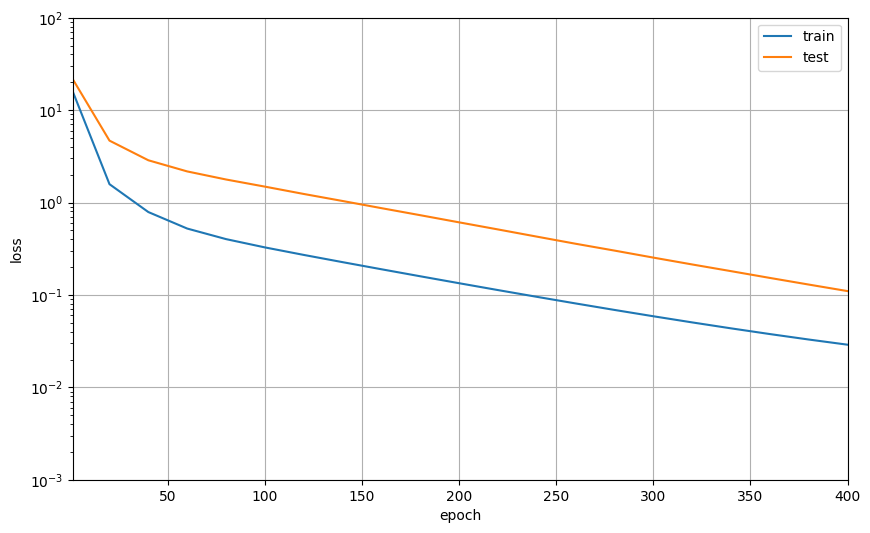

weight: [[ 4.986181   1.4888877 -3.3319256  4.678516 ]]


Sequential(
  (0): Linear(in_features=4, out_features=1, bias=False)
)

In [7]:
# 從多項式特徵中選擇前4個維度，即1,x,x^2/2!,x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

### [**線性函數擬合(欠擬合)**]

讓我們再看看線性函數擬合，減少該模型的訓練損失相對困難。
在最后一個迭代週期完成後，訓練損失仍然很高。
當用來擬合非線性模式（如這裡的三階多項式函數）時，線性模型容易欠擬合。


epoch 1, train loss 18.294, test loss 25.304
epoch 20, train loss 2.364, test loss 6.916
epoch 40, train loss 2.351, test loss 6.694
epoch 60, train loss 2.351, test loss 6.677
epoch 80, train loss 2.351, test loss 6.674
epoch 100, train loss 2.351, test loss 6.686
epoch 120, train loss 2.351, test loss 6.676
epoch 140, train loss 2.351, test loss 6.679
epoch 160, train loss 2.351, test loss 6.685
epoch 180, train loss 2.351, test loss 6.688
epoch 200, train loss 2.351, test loss 6.685
epoch 220, train loss 2.351, test loss 6.670
epoch 240, train loss 2.351, test loss 6.677
epoch 260, train loss 2.351, test loss 6.683
epoch 280, train loss 2.351, test loss 6.689
epoch 300, train loss 2.351, test loss 6.689
epoch 320, train loss 2.351, test loss 6.689
epoch 340, train loss 2.351, test loss 6.670
epoch 360, train loss 2.351, test loss 6.663
epoch 380, train loss 2.351, test loss 6.673
epoch 400, train loss 2.351, test loss 6.671


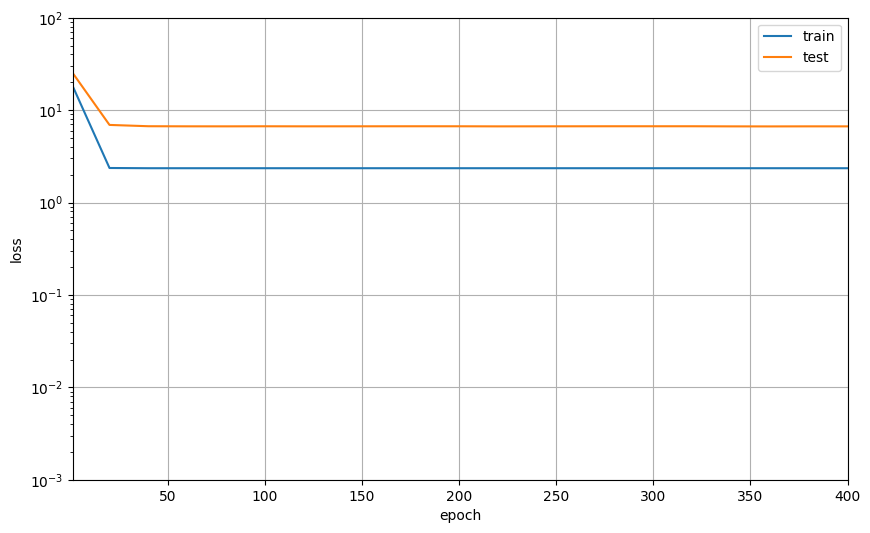

weight: [[3.8914998 2.4993303]]


Sequential(
  (0): Linear(in_features=2, out_features=1, bias=False)
)

In [8]:
# 從多項式特徵中選擇前2個維度，即1和x
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

### [**高階多項式函數擬合(過擬合)**]

現在，讓我們嘗試使用一個階數過高的多項式來訓練模型。
在這種情況下，沒有足夠的資料用於學到高階係數應該具有接近於零的值。
因此，這個過於複雜的模型會輕易受到訓練資料中雜訊的影響。
雖然訓練損失可以有效地降低，但測試損失仍然很高。
結果表明，複雜模型對資料造成了過擬合。


epoch 1, train loss 16.663, test loss 21.667
epoch 20, train loss 1.512, test loss 4.227
epoch 40, train loss 0.692, test loss 2.364
epoch 60, train loss 0.441, test loss 1.741
epoch 80, train loss 0.333, test loss 1.405
epoch 100, train loss 0.268, test loss 1.164
epoch 120, train loss 0.220, test loss 0.952
epoch 140, train loss 0.182, test loss 0.786
epoch 160, train loss 0.151, test loss 0.644
epoch 180, train loss 0.125, test loss 0.526
epoch 200, train loss 0.105, test loss 0.431
epoch 220, train loss 0.088, test loss 0.352
epoch 240, train loss 0.074, test loss 0.288
epoch 260, train loss 0.062, test loss 0.235
epoch 280, train loss 0.053, test loss 0.193
epoch 300, train loss 0.045, test loss 0.158
epoch 320, train loss 0.039, test loss 0.130
epoch 340, train loss 0.034, test loss 0.107
epoch 360, train loss 0.029, test loss 0.088
epoch 380, train loss 0.026, test loss 0.073
epoch 400, train loss 0.023, test loss 0.060
epoch 420, train loss 0.021, test loss 0.050
epoch 440, tra

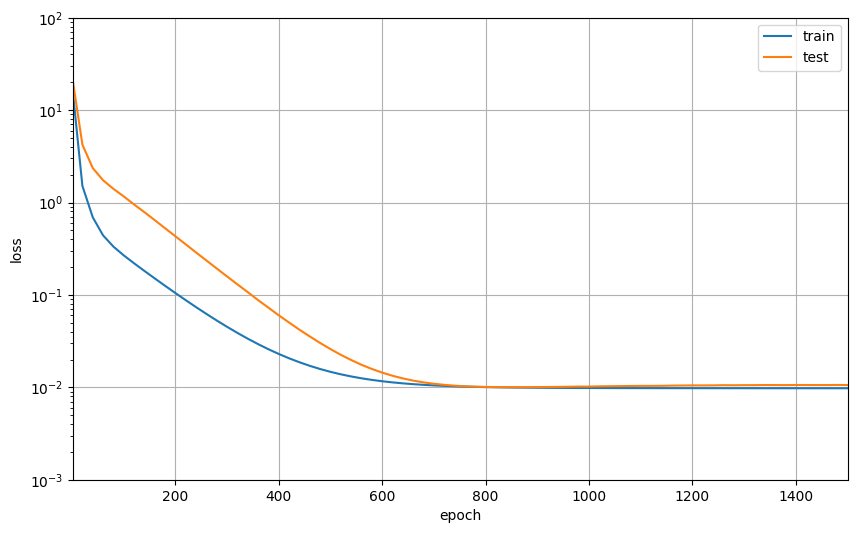

weight: [[ 5.0154967   1.2567294  -3.4326167   5.285513   -0.07377783  1.1722509
   0.12649722  0.16676024 -0.08471328  0.01383498  0.03870592 -0.07227868
   0.00659843  0.16310383 -0.18916613  0.02913615 -0.13781841 -0.07726908
   0.01220259 -0.14033464]]


Sequential(
  (0): Linear(in_features=20, out_features=1, bias=False)
)

In [9]:
# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)

在接下來的章節中，我們將繼續討論過擬合問題和處理這些問題的方法，例如權重衰減和dropout。

## 小結

* 欠擬合是指模型無法繼續減少訓練誤差。過擬合是指訓練誤差遠小於驗證誤差。
* 由於不能基於訓練誤差來估計泛化誤差，因此簡單地最小化訓練誤差並不一定意味著泛化誤差的減小。機器學習模型需要注意防止過擬合，即防止泛化誤差過大。
* 驗證集可以用于模型選擇，但不能過於隨意地使用它。
* 我們應該選擇一個複雜度適當的模型，避免使用數量不足的訓練樣本。

## 練習

1. 這個多項式回歸問題可以準確地解出嗎？提示：使用線性代數。
1. 考慮多項式的模型選擇。
    1. 繪製訓練損失與模型複雜度（多項式的階數）的關係圖。觀察到了什麼？需要多少階的多項式才能將訓練損失減少到0?
    1. 在這種情況下繪製測試的損失圖。
    1. 生成同樣的圖，作為資料量的函數。
1. 如果不對多項式特徵$x^i$進行標準化($1/i!$)，會發生什麼事情？能用其他方法解決這個問題嗎？
1. 泛化誤差可能為零嗎？


[Discussions](https://discuss.d2l.ai/t/1806)


練習一:

1. 這個多項式回歸問題可以準確地解出嗎？提示：使用線性代數。

我的回答加上AI的潤色:

**答案解析：**  
在純理想情況下（假設資料點之間不存在矛盾、沒有額外雜訊），多項式回歸在理論上是可以「精準」解出的。以下說明為什麼可以透過線性代數來得到多項式的確切解答：

---

### 1. 建立設計矩陣（Design Matrix）

假設我們有 $ n $   組訓練數據 $\{(x_i, y_i)\}_{i=1}^n$，並希望擬合一個 $d$ 次多項式：

$$
\hat{y} = w_0 + w_1 x + w_2 x^2 + \cdots + w_d x^d \,.
$$

我們可以定義設計矩陣 $X$（大小為 $n \times (d+1)$），其中第 $i$ 列為：

$$
[\, 1,\; x_i,\; x_i^2,\; \ldots,\; x_i^d \,].
$$

同時將所有目標值 $y_i$ 組成向量：

$$
\mathbf{y} = 
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}.
$$

---

### 2. 建立線性方程

若我們用向量 $\mathbf{w} = [w_0, w_1, \ldots, w_d]^\top$ 表示多項式的係數，那麼在沒有任何雜訊、且希望精準擬合所有資料點的情況下，可以寫成矩陣方程式：

$$
X \mathbf{w} = \mathbf{y}.
$$

只要 $X$ 的列數與行數關係允許（例如資料點數量 $n$ 與多項式階數 $d$ 之間的關係合理），並且 $X$ 滿秩（full rank），這個方程就可能有唯一解。

---

### 3. 使用正常方程（Normal Equation）或直接求解

1. **正常方程**：在最小平方法的架構下，若想要找到使 $\| X\mathbf{w} - \mathbf{y} \|$ 最小的 $\mathbf{w}$，可以使用  
   $$
   \mathbf{w} = (X^\top X)^{-1} X^\top \mathbf{y},
   $$  
   只要 $X^\top X$ 是可逆的，就能得到一組唯一解。

2. **直接求解**：若你希望精準經過所有點（無雜訊、無多重解），且採用的多項式階數為 $d = n-1$（或更小而仍足以滿足條件），則可以透過求解方程 $X \mathbf{w} = \mathbf{y}$ 直接找到精準擬合所有點的多項式。如果使用的是 Vandermonde 矩陣（即上面所說設計矩陣的一種形式），只要所有 $x_i$ 彼此不同，且資料一致，便可透過矩陣運算得到唯一解。

---

### 4. 實務上的考量：過度擬合與數值不穩定

1. **過度擬合 (Overfitting)**  
   - 若多項式階數選得過高 (例如用 $n-1$ 階多項式去擬合 $n$ 點)，雖然能在訓練資料上達到「零誤差」，卻可能在新資料（測試集）上表現不佳。  

2. **數值穩定性**  
   - 當 $d$ 很大時（尤其 $d$ 接近 $n-1$），Vandermonde 矩陣可能導致極度病態（condition number 非常大），使得反矩陣計算不穩定，容易受到微小浮點誤差影響，造成不準確或發散。

---

### 5. 總結

- **是否能「精準」解出**：  
  是的，如果資料沒有雜訊且滿足一定條件（如 $n$ 個樣本、$d \le n-1$ 的多項式階數、Vandermonde 矩陣可逆），就能透過線性代數的方法（如正常方程或直接解方程組）得到唯一且精確的解。

- **實務建議**：  
  若實際場景中有雜訊或考量泛化能力，一味追求「精準經過所有點」往往不是好主意，可能導致嚴重的過度擬合。通常我們會根據資料性質和模型複雜度的平衡，選擇適當階數（或使用正規化等技巧）。

因此，在理想且無雜訊的條件下，這個多項式回歸問題「可以」透過線性代數手段準確解出，但實務上仍需結合正則化與泛化誤差的考量，才能得到對新數據有良好預測力的模型。


練習二:

2. 考慮多項式的模型選擇。
    1. 繪製訓練損失與模型複雜度（多項式的階數）的關係圖。觀察到了什麼？需要多少階的多項式才能將訓練損失減少到0?
    2. 在這種情況下繪製測試的損失圖。
    3. 生成同樣的圖，作為資料量的函數。

我的回答:

以下以「多項式模型」為例，說明在調整不同階數（模型複雜度）以及改變訓練資料量時，對訓練損失與測試損失所造成的影響。由於這些問題牽涉到繪製圖表與觀察曲線，以下先給出大致的流程及可能觀察到的結果，並附帶一些解釋。

---

## 1. 繪製「訓練損失 vs. 多項式階數」的關係圖

1. **基本流程**  
   1. 準備一組固定的訓練資料，假設其大小為 $N$。  
   2. 設定一系列可能的多項式階數（例如從 1 階、2 階、3 階，一直到 $N-1$ 階，如果資料量允許的話）。  
   3. 對每個階數，訓練一個多項式回歸模型，並計算其在訓練資料上的損失（如 MSE）。  
   4. 將「多項式階數」作為 x 軸，「訓練損失」作為 y 軸，繪製曲線。

2. **觀察結果**  
   - 隨著多項式階數（模型複雜度）不斷增加，模型能更靈活地「擬合」訓練資料，因此「訓練損失」通常會下降。  
   - 在極端情況下，若多項式階數能達到 $N-1$（且假設沒有雜訊或雜訊很小），理論上可以讓模型「完美」地通過所有訓練點，使 **訓練損失接近 0**。  
   - 因此，可以觀察到，**只要多項式階數足夠高（可能等於或略高於資料點數目減 1），訓練損失可以降到 0**。  

3. **需要多少階數才能將訓練損失減到 0**  
   - 理想條件下，若資料點是 $(x_i, y_i)$ 且彼此間無重疊與矛盾，**多項式階數 $d \ge N - 1$**（或接近）就能讓訓練損失為 0。  
   - 然而，若資料本身存在雜訊（或不可能完美擬合的現象），則即使階數很高，損失也可能無法真正到達 0，但還是會非常小。

---

## 2. 在「同樣情境」下繪製測試損失圖

1. **基本流程**  
   - 將上一步訓練好的各種多項式模型（不同階數）分別在相同的測試資料上評估損失。  
   - 「多項式階數」為 x 軸，「測試損失」為 y 軸，繪製曲線。

2. **預期現象：過度擬合**  
   - 當多項式階數較低時，模型可能欠擬合（underfitting），導致測試損失相對較高。  
   - 當階數適中時，測試損失下降並達到一個相對低點，此時模型能較好地擬合整體資料而不過度擬合。  
   - 若繼續增加階數，模型可能會針對訓練集做過度擬合，雖然訓練損失幾近 0，但測試損失會開始反彈、上升。  
   - 因此，我們通常能在此圖中觀察到一條「U 型曲線」或類似型態：先下降後上升的趨勢。模型選擇時一般會挑選曲線谷底（測試損失最小）對應的階數。

---

## 3. 生成相同的圖表，作為「資料量」的函數

在前兩小節中，我們將「多項式階數」視為主要自變量，如今改成「訓練資料量」作為自變量來觀察模型表現。

1. **基本概念**  
   - 將訓練資料大小由小到大（如 10 筆、50 筆、100 筆、…）逐漸增加，並且固定多項式階數或嘗試不同階數來觀察訓練與測試損失的變化。  
   - 可以分別繪製：  
     - **訓練損失 vs. 資料量**  
     - **測試損失 vs. 資料量**  

2. **結果與解釋**  
   - **訓練損失 vs. 資料量**  
     - 若資料量極小，模型往往能「完美」記住這些資料（訓練損失很低甚至 0），但不一定能泛化。  
     - 資料量逐漸增加時，模型不再能只靠「硬記」，訓練損失可能略微上升或保持在一個穩定水準，但學到的規律通常更具泛化性。  
   - **測試損失 vs. 資料量**  
     - 通常隨著訓練資料的增加，模型的測試損失會下降，表示模型的泛化能力提升。  
     - 在資料不足時，容易過度擬合；擁有充分資料後，即使採用適度高階的多項式，也能穩定泛化。

3. **綜合評估**  
   - 在實際應用中，我們會透過觀察「模型複雜度（多項式階數）」以及「資料量」兩者對於訓練損失與測試損失的影響，來做**模型選擇**（挑選適合的階數、評估是否需要更多資料或更好的正則化方法）。  
   - 若資料量實際不充足，又硬要用過高階數，往往會導致測試損失不斷上升，即出現過度擬合現象。

---

## 小結

1. **訓練損失 vs. 模型複雜度（階數）**  
   - 多項式階數越高，訓練損失通常越低；在理想情況（無雜訊）下，多項式階數達到 $N-1$ 時，訓練損失可以降至 0。  
   - 但此時往往伴隨過度擬合，導致測試損失偏高。

2. **測試損失 vs. 模型複雜度（階數）**  
   - 一開始階數提升能降低測試損失，但超過某個程度後，測試損失開始反彈；最佳的階數常出現在測試損失曲線的谷底位置。

3. **損失 vs. 資料量**  
   - 資料量越少，容易記住所有訓練資料（訓練損失可能很低），但測試損失高。  
   - 資料量增加，通常有助於提高模型的泛化能力，使測試損失下降。

這些實驗與圖表能幫助我們理解「模型複雜度」、「訓練樣本數量」與「過擬合/欠擬合」之間的關係，並在實際專案中用來協助挑選合適的多項式階數或決定是否需要收集更多資料。


練習三:

3. 如果不對多項式特徵$x^i$進行標準化($1/i!$)，會發生什麼事情？能用其他方法解決這個問題嗎？

我的回答加上AI的潤色:

**第一段：為何需要對多項式特徵進行縮放或標準化**  
當我們將輸入 $x$ 擴增為多項式特徵 $x^1, x^2, \dots, x^d$ 時，若 $x$ 的取值範圍較大（譬如大於 1），則高次項（例如 $x^d$）的數值可能在數值上變得非常大；相反地，若 $x$ 的取值範圍小於 1，則高次項可能變得極度微小。這些**數值尺度的劇烈變化**，常常會導致以下問題：

1. **梯度爆炸或梯度消失**：在參與梯度計算時，過大或過小的特徵值容易造成權重更新幅度難以掌控，損害訓練穩定度。  
2. **數值不穩定性**：若使用了如 $(X^\top X)^{-1}$ 這類矩陣運算（例如正常方程），在高維多項式情況下更容易出現病態條件數（condition number 非常大）。  
3. **訓練效果與收斂速度受影響**：特徵縮放不當會造成部分維度在優化過程中主導權重更新，而其他維度被忽視。

因此，有些做法會直接對多項式特徵 $x^i$ 乘以 $\frac{1}{i!}$ 或其他縮放因子，以減緩高次項的數值爆炸。

---

**第二段：如果不對多項式特徵做標準化，會發生什麼事**  
- **特徵值差異巨大**：若 $x$ 的數值稍大於 1，譬如 2、3 甚至更大，則 $x^d$ 可能遠大於 $x$ 或其他低次項，使得訓練模型時，權重更新主要依賴於高次項，容易發生不穩定情況。  
- **優化變得困難**：在梯度下降或其他優化器（如 Adam）運作下，高次項產生的大量梯度可能造成參數劇烈震盪，而小次項的影響相對忽略，導致訓練不易收斂，或收斂到次佳解。  
- **模型不易解釋**：在缺乏適當縮放時，高次項的權重會有相對極端的數值（可能非常大或非常小），使得後續分析模型時不便判斷各項影響程度。

---

**第三段：能用哪些其他方法解決這個問題？**  

1. **一般化的特徵縮放（Feature Scaling）**  
   - 對每個多項式特徵單獨計算其平均值與標準差（或最大最小值），然後進行 Z-score 標準化或 min-max 歸一化。  
   - 這樣能確保所有特徵的數值範圍大致相當，減少高次項與低次項之間的數量級落差。

2. **正交（Orthonormal）多項式**  
   - 使用如**勒讓德多項式（Legendre polynomials）**、**切比雪夫多項式（Chebyshev polynomials）**等正交基底來取代單純的 $x^i$。  
   - 正交多項式具備更好的數值性質，能在一定程度上保持特徵之間的不相關性，並降低多重共線性與矩陣病態性。  
   - 雖然這種方法在實作上稍微複雜，但對高階多項式擬合來說可能更為穩定。

3. **在訓練流程中使用適當的正規化手段**  
   - 若不得不用高階項，可以考慮加強正規化（如 **L2 權重衰減**）或 **dropout**、**早停 (early stopping)** 等，降低模型對高次項的過度依賴，減少過度擬合及訓練不穩定的風險。  

4. **選擇適度的多項式階數**  
   - 在資料量有限、或對泛化要求較高的情況下，避免盲目擴增到非常高階。保持較低階的多項式或配合正規化方法，可提升模型的穩定性與可解釋度。

---

**總結**  
若不對多項式特徵 $x^i$ 做任何標準化（例如 $\frac{1}{i!}$），可能造成嚴重的數值不穩定與優化困難。除此之外，我們也可以藉由**一般化的特徵縮放**、**使用正交多項式**、**正規化方法**或**適度控制多項式階數**來減少高次項放大的影響，以達到更穩定且高效的訓練過程。

練習四:

4. 泛化誤差可能為零嗎？

我的回答加上AI的潤色:

**第一段：理論上的可能性**  
從嚴格的數學角度來看，如果資料及目標函數（target function）沒有任何雜訊或隨機性，且模型的容量（capacity）足夠大並能精準擬合整個真實分佈，那麼在理想情況下，「泛化誤差」可以趨近於零。這在一些完全人工、無雜訊的小型資料集（或理想化的合成數據）中，理論上是可能發生的。

---

**第二段：實務上的現實**  
然而，在真實世界的大多數問題中，資料往往帶有雜訊、不完美標記或本質上的隨機性，不可能存在能夠「完美」擬合並對所有未見資料都給出正確預測的模型。即使模型在訓練集上能達到幾乎 0 的訓練誤差，也往往會在測試集（或真實應用場景中）出現差異，導致泛化誤差大於 0。

---

**第三段：造成無法達成零誤差的主要原因**  
1. **資料雜訊**：真實資料常包含測量誤差或先天隨機因素，導致無法被「精準」學習。  
2. **模型偏差與方差**：模型若太簡單，容易欠擬合；若太複雜，則可能過度擬合，雖然訓練誤差接近零，但泛化誤差反而上升。  
3. **資料分佈動態性**：現實場景中，資料分佈常隨時間或環境改變，導致模型若只依訓練資料所學到的規律，未必能完美應對新情況。

---

**第四段：綜合結論**  
- **理論上**：在沒有任何雜訊且能完全掌握資料分佈的極端條件下，模型泛化誤差「可能」趨近於零。  
- **實務上**：大多數真實世界任務中，由於資料雜訊、分佈複雜度以及模型對未見資料的不可控因素，泛化誤差幾乎不可能真正達到零。換言之，在真實情境裡，我們通常只能努力讓泛化誤差盡量小，而很難讓它完全消失。
